## M.Avinash (2303A52465) B-50


# Libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


Load Data set

In [30]:
df = pd.read_csv("/content/mobile_usage_behavioral_analysis.csv")
print("Dataset shape:", df.shape)
df

Dataset shape: (1000, 10)


,User_ID,Age,Gender,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours,Location
0,1,56,Male,2.61,7.15,24,4.43,0.55,2.40,Los Angeles
1,2,46,Male,2.13,13.79,18,4.67,4.42,2.43,Chicago
2,3,32,Female,7.28,4.50,11,4.58,1.71,2.83,Houston
3,4,25,Female,1.20,6.29,21,3.18,3.42,4.58,Phoenix
4,5,38,Male,6.31,12.59,14,3.15,0.13,4.00,New York
...,...,...,...,...,...,...,...,...,...,...
995,996,41,Female,3.58,12.46,13,4.12,2.44,1.33,Los Angeles
996,997,32,Male,9.65,10.51,11,1.02,1.02,3.84,Los Angeles
997,998,46,Female,11.68,10.06,9,2.35,3.13,1.03,Phoenix
998,999,25,Male,3.89,10.78,15,4.00,1.79,1.61,Phoenix


 Preprocessing

In [31]:
target = "Daily_Screen_Time_Hours"
X = df.drop(columns=[target])
y = df[target]

X = pd.get_dummies(X, drop_first=True)

print("Final features shape:", X.shape)
X

Final features shape: (1000, 12)


,User_ID,Age,Total_App_Usage_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours,Gender_Male,Location_Houston,Location_Los Angeles,Location_New York,Location_Phoenix
0,1,56,2.61,24,4.43,0.55,2.40,True,False,True,False,False
1,2,46,2.13,18,4.67,4.42,2.43,True,False,False,False,False
2,3,32,7.28,11,4.58,1.71,2.83,False,True,False,False,False
3,4,25,1.20,21,3.18,3.42,4.58,False,False,False,False,True
4,5,38,6.31,14,3.15,0.13,4.00,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,41,3.58,13,4.12,2.44,1.33,False,False,True,False,False
996,997,32,9.65,11,1.02,1.02,3.84,True,False,True,False,False
997,998,46,11.68,9,2.35,3.13,1.03,False,False,False,False,True
998,999,25,3.89,15,4.00,1.79,1.61,True,False,False,False,True


Training and spliting

In [32]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)


RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

Evaluate Model

In [38]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.3f}")


Model Performance:
RMSE: 3.97
MAE:  3.43
R²:   -0.121


SHAP Explainer Setup

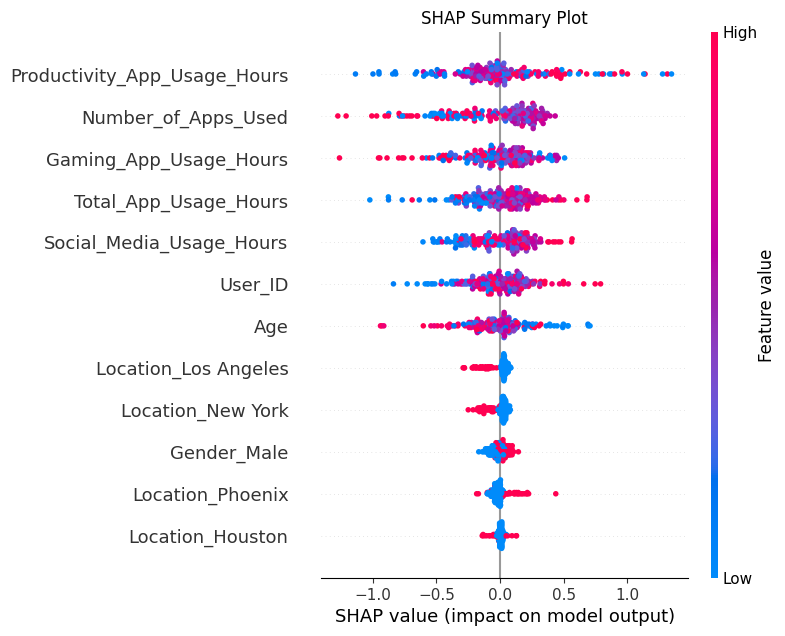

In [34]:
explainer = shap.TreeExplainer(model)
X_sample = X_test.sample(n=200, random_state=42)
shap_values = explainer.shap_values(X_sample)
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Summary Plot")
plt.show()

#SHAP Dependence plot

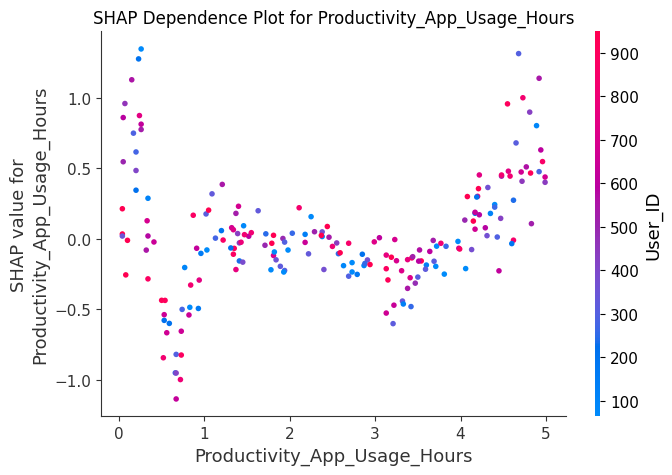

In [35]:
top_feature = X.columns[np.argsort(np.abs(shap_values).mean(axis=0))[::-1][0]]
shap.dependence_plot(top_feature, shap_values, X_sample, show=False)
plt.title(f"SHAP Dependence Plot for {top_feature}")
plt.show()

SHAP WAterwall plot

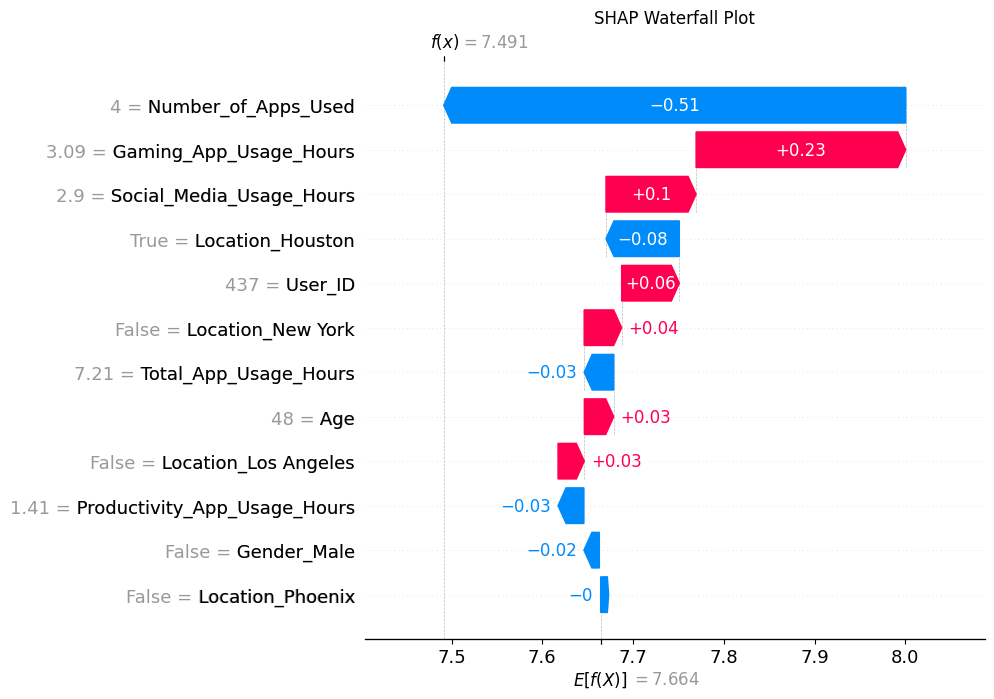

In [36]:
i = 0  # pick the first row in sample
exp = shap.Explanation(
    values=shap_values[i],
    base_values=np.array([explainer.expected_value]),
    data=X_sample.iloc[i, :].values,
    feature_names=X_sample.columns.tolist()
)
shap.plots.waterfall(exp, max_display=12, show=False)
plt.title("SHAP Waterfall Plot")
plt.show()

Feature Importance

In [37]:
importances = pd.Series(model.feature_importances_, index=X.columns)
print("\nTop 10 features by model importance:")
importances.sort_values(ascending=False).head(10)



Top 10 features by model importance:


,0
Productivity_App_Usage_Hours,0.148760
Total_App_Usage_Hours,0.142381
Gaming_App_Usage_Hours,0.137848
Social_Media_Usage_Hours,0.137325
User_ID,0.136688
Age,0.120794
Number_of_Apps_Used,0.102329
Location_Phoenix,0.018282
Gender_Male,0.016962
Location_New York,0.013326
